# Layerwise static dRSA metric difference

This notebook loads two sets of static dRSA similarity timecourses, subtracts metric B from metric A layer by layer, and plots the two original timecourses plus their difference.

In [ ]:
import os, sys, yaml
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "python_scripts" else Path.cwd().parents[1]
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)

paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
if "useful_stuff_path" in paths:
    sys.path.append(paths["useful_stuff_path"])

from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from useful_stuff.general_utils.plots import truncate_colormap

In [19]:
@dataclass
class Cfg:
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str = "AIT"
    metric_a_signal: str = "cosine"
    metric_a_model: str = "cosine_cnt"
    metric_b_signal: str = "magnitude_diff"
    metric_b_model: str = "cosine_cnt"
    model_name: str = "vit_l_16"
    img_size: int = 384
    new_fs: int = 100
    pkg: str = "timm"
    results_dir: Path = Path(paths["data_path"]) / "results"
    cmap_name: str = "plasma"
    line_width: float = 3.0
    alpha: float = 0.9
    labelsize: int = 24
    ticksize: int = 16
    normalize_similarity_timecourses: bool = False
    diff_or_sum: str = "sum"

cfg = Cfg()
cfg

Cfg(monkey_name='three0', date='250313', brain_area='AIT', metric_a_signal='cosine', metric_a_model='cosine_cnt', metric_b_signal='magnitude_diff', metric_b_model='cosine_cnt', model_name='vit_l_16', img_size=384, new_fs=100, pkg='timm', results_dir=PosixPath('/Users/tizianocausin/metrics_II_local/results'), cmap_name='plasma', line_width=3.0, alpha=0.9, labelsize=24, ticksize=16, normalize_similarity_timecourses=False, diff_or_sum='sum')

In [20]:
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
metric_a_label = f"{cfg.metric_a_signal}-{cfg.metric_a_model}"
metric_b_label = f"{cfg.metric_b_signal}-{cfg.metric_b_model}"
if cfg.normalize_similarity_timecourses:
    similarity_ylabel = "Min-max normalized RSA similarity"
    difference_ylabel = "Normalized similarity difference"
    difference_label = f"normalized({metric_a_label}) - normalized({metric_b_label})"
else:
    similarity_ylabel = "RSA similarity"
    difference_ylabel = "Similarity difference"
    difference_label = f"{metric_a_label} - {metric_b_label}"

print(f"{len(layers)} layers")
print(f"metric A: {metric_a_label}")
print(f"metric B: {metric_b_label}")
print(f"min-max normalize timecourses: {cfg.normalize_similarity_timecourses}")

24 layers
metric A: cosine-cosine_cnt
metric B: magnitude_diff-cosine_cnt
min-max normalize timecourses: False


In [21]:
def static_drsa_save_name(signal_metric, model_metric, layer_name):
    return cfg.results_dir / (
        f"static_dRSA_{signal_metric}-{model_metric}_"
        f"{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_"
        f"{cfg.model_name}_{cfg.img_size}_{layer_name}_{cfg.new_fs}Hz.npz"
    )


def load_static_drsa_curves(signal_metric, model_metric):
    curves = {}
    missing = []
    for layer_name in layers:
        save_name = static_drsa_save_name(signal_metric, model_metric, layer_name)
        if save_name.exists():
            curves[layer_name] = np.load(save_name)["arr_0"]
        else:
            missing.append(save_name)
    return curves, missing


curves_a, missing_a = load_static_drsa_curves(cfg.metric_a_signal, cfg.metric_a_model)
curves_b, missing_b = load_static_drsa_curves(cfg.metric_b_signal, cfg.metric_b_model)
common_layers = [layer_name for layer_name in layers if layer_name in curves_a and layer_name in curves_b]

if not common_layers:
    raise FileNotFoundError(
        f"No common layers found for {metric_a_label} and {metric_b_label} in {cfg.results_dir}"
    )

print(f"loaded metric A: {len(curves_a)} / {len(layers)} layers")
print(f"loaded metric B: {len(curves_b)} / {len(layers)} layers")
print(f"common layers: {len(common_layers)} / {len(layers)}")
if missing_a:
    print(f"missing metric A files: {len(missing_a)}")
    for save_name in missing_a[:5]:
        print(save_name)
if missing_b:
    print(f"missing metric B files: {len(missing_b)}")
    for save_name in missing_b[:5]:
        print(save_name)

loaded metric A: 24 / 24 layers
loaded metric B: 24 / 24 layers
common layers: 24 / 24


In [22]:
difference_curves = {}
aligned_curves_a = {}
aligned_curves_b = {}

def min_max_normalize_timecourse(curve):
    curve = np.asarray(curve, dtype=float).copy()
    finite = np.isfinite(curve)
    if not np.any(finite):
        return curve
    min_value = np.nanmin(curve)
    max_value = np.nanmax(curve)
    value_range = max_value - min_value
    if value_range == 0:
        curve[finite] = 0.0
        return curve
    curve[finite] = (curve[finite] - min_value) / value_range
    return curve


for layer_name in common_layers:
    a = np.asarray(curves_a[layer_name], dtype=float)
    b = np.asarray(curves_b[layer_name], dtype=float)
    n = min(a.size, b.size)
    if a.size != b.size:
        print(f"Warning: trimming {layer_name} from lengths {a.size}, {b.size} to {n}")
    a = a[:n]
    b = b[:n]
    if cfg.normalize_similarity_timecourses:
        a = min_max_normalize_timecourse(a)
        b = min_max_normalize_timecourse(b)
    aligned_curves_a[layer_name] = a[:n]
    aligned_curves_b[layer_name] = b[:n]
    if cfg.diff_or_sum == "diff":
        difference_curves[layer_name] = a - b
    elif cfg.diff_or_sum == "sum":
        difference_curves[layer_name] = a + b
    

print(f"computed layerwise difference: {difference_label}")
if cfg.normalize_similarity_timecourses:
    print("Each metric timecourse was independently min-max normalized within each layer before subtraction.")

computed layerwise difference: cosine-cosine_cnt - magnitude_diff-cosine_cnt


## Timecourses by layer depth

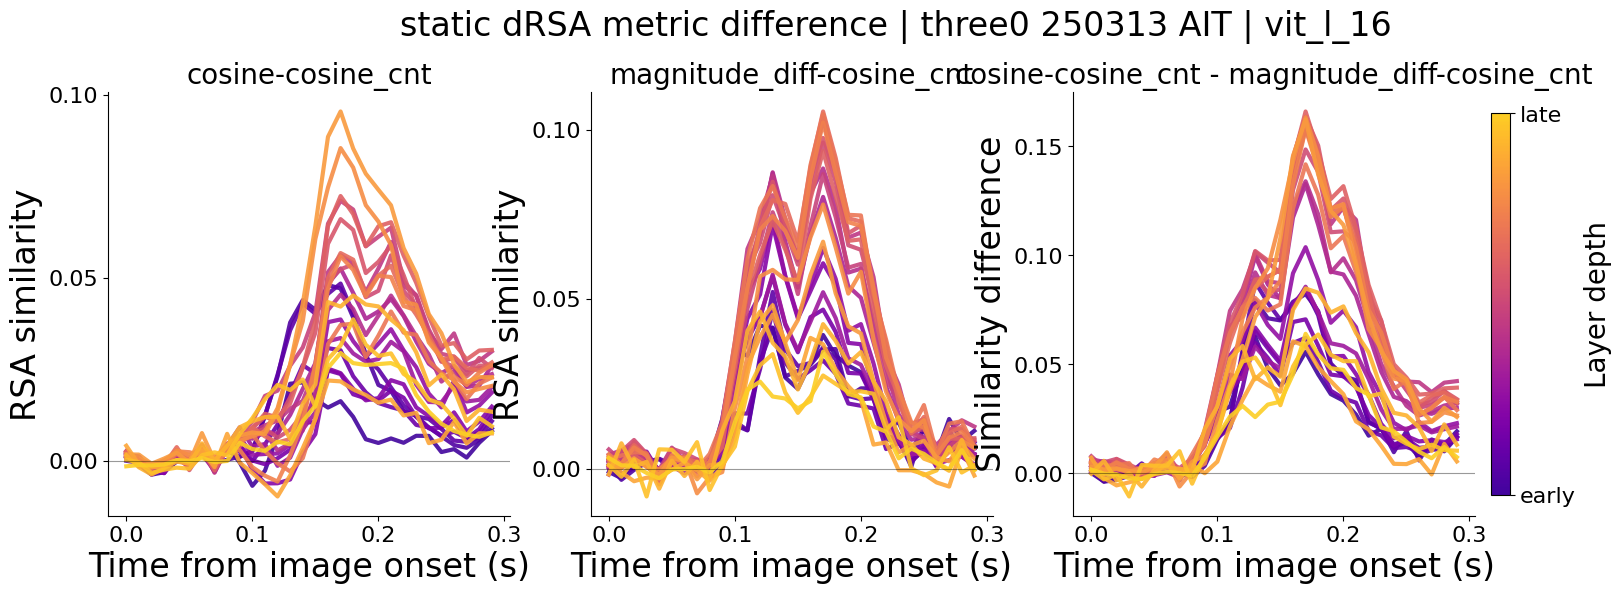

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5.5), sharex=True)
cmap = truncate_colormap(mpl.colormaps[cfg.cmap_name])
norm = mpl.colors.Normalize(vmin=0, vmax=len(layers) - 1)

panels = [
    (axes[0], aligned_curves_a, metric_a_label, similarity_ylabel),
    (axes[1], aligned_curves_b, metric_b_label, similarity_ylabel),
    (axes[2], difference_curves, difference_label, difference_ylabel),
]

for ax, curves, title, ylabel in panels:
    for layer_idx, layer_name in enumerate(layers):
        if layer_name not in curves:
            continue
        y = curves[layer_name]
        t = np.arange(y.size) / cfg.new_fs
        ax.plot(
            t,
            y,
            color=cmap(norm(layer_idx)),
            linewidth=cfg.line_width,
            alpha=cfg.alpha,
            label=layer_name,
        )

    ax.axhline(0, color="black", linewidth=0.8, alpha=0.4)
    ax.set_title(title, fontsize=cfg.labelsize - 4)
    ax.set_xlabel("Time from image onset (s)", fontsize=cfg.labelsize)
    ax.set_ylabel(ylabel, fontsize=cfg.labelsize)
    ax.tick_params(axis="both", labelsize=cfg.ticksize)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=axes, pad=0.01, shrink=0.9)
cbar.set_ticks([0, len(layers) - 1])
cbar.set_ticklabels(["early", "late"], fontsize=cfg.ticksize)
cbar.set_label("Layer depth", fontsize=cfg.ticksize + 4, labelpad=6)

fig.suptitle(
    f"static dRSA metric difference | {cfg.monkey_name} {cfg.date} {cfg.brain_area} | {cfg.model_name}",
    fontsize=cfg.labelsize,
    y=1.03,
)
# plt.tight_layout()
plt.show()

## Peak similarity and peak difference across layers

In [ ]:
depths = []
depth_labels = []
peak_a = []
peak_b = []
peak_diff = []
mean_diff = []

for layer_idx, layer_name in enumerate(layers):
    if layer_name not in difference_curves:
        continue
    depths.append(layer_idx)
    depth_labels.append(layer_name)
    peak_a.append(np.nanmax(aligned_curves_a[layer_name]))
    peak_b.append(np.nanmax(aligned_curves_b[layer_name]))
    peak_diff.append(np.nanmax(difference_curves[layer_name]))
    mean_diff.append(np.nanmean(difference_curves[layer_name]))

fig, (ax_peak, ax_diff) = plt.subplots(1, 2, figsize=(16, 5.5), sharex=True)

ax_peak.plot(depths, peak_a, color="tab:blue", linewidth=2, marker="o", label=metric_a_label)
ax_peak.plot(depths, peak_b, color="tab:orange", linewidth=2, marker="o", label=metric_b_label)
ax_peak.set_ylabel(f"Peak {similarity_ylabel.lower()}", fontsize=cfg.labelsize)
ax_peak.legend(frameon=False, fontsize=cfg.ticksize - 2)

ax_diff.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax_diff.plot(depths, peak_diff, color="tab:green", linewidth=2, marker="o", label="peak difference")
ax_diff.plot(depths, mean_diff, color="black", linewidth=2, marker="o", label="mean difference")
ax_diff.set_ylabel(difference_ylabel, fontsize=cfg.labelsize)
ax_diff.legend(frameon=False, fontsize=cfg.ticksize - 2)

for ax in (ax_peak, ax_diff):
    ax.set_xlabel("Layer depth", fontsize=cfg.labelsize)
    ax.set_xticks(depths)
    ax.set_xticklabels(depth_labels, rotation=90, fontsize=max(cfg.ticksize - 6, 8))
    ax.tick_params(axis="y", labelsize=cfg.ticksize)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))

fig.suptitle(f"Layerwise summary | {difference_label}", fontsize=cfg.labelsize, y=1.02)
plt.tight_layout()
plt.show()

## Per-layer overlays

In [ ]:
n_cols = 4
n_rows = int(np.ceil(len(layers) / n_cols))
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.4 * n_cols, 2.8 * n_rows),
    sharex=True,
    sharey=False,
)
axes = np.asarray(axes).ravel()

for layer_idx, layer_name in enumerate(layers):
    ax = axes[layer_idx]
    if layer_name not in difference_curves:
        ax.text(0.5, 0.5, "missing", transform=ax.transAxes, ha="center", va="center")
        ax.set_title(layer_name, fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
        continue

    t = np.arange(difference_curves[layer_name].size) / cfg.new_fs
    ax.plot(t, aligned_curves_a[layer_name], color="tab:blue", linewidth=1.6, alpha=0.9)
    ax.plot(t, aligned_curves_b[layer_name], color="tab:orange", linewidth=1.6, alpha=0.9)
    ax.plot(t, difference_curves[layer_name], color="black", linewidth=1.4, alpha=0.85, linestyle="--")
    ax.axhline(0, color="black", linewidth=0.6, alpha=0.35)
    ax.set_title(layer_name, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[len(layers):]:
    ax.axis("off")

for ax in axes[-n_cols:]:
    ax.set_xlabel("Time (s)")
for ax in axes[::n_cols]:
    ax.set_ylabel("static dRSA" if not cfg.normalize_similarity_timecourses else "normalized static dRSA")

legend_handles = [
    mpl.lines.Line2D([0], [0], color="tab:blue", linewidth=1.8, label=metric_a_label),
    mpl.lines.Line2D([0], [0], color="tab:orange", linewidth=1.8, label=metric_b_label),
    mpl.lines.Line2D([0], [0], color="black", linewidth=1.6, linestyle="--", label="A - B"),
]
fig.legend(
    handles=legend_handles,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.975),
    ncol=3,
)
fig.suptitle(
    f"static dRSA layerwise overlays | {cfg.monkey_name} {cfg.date} {cfg.brain_area} | {cfg.model_name}",
    y=1.005,
)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()